# Welcome to Colab!

In [2]:
import pandas as pd

df = pd.read_csv("ecommerce_customer_churn_large.csv")

df.head()

,customer_id,age,gender,city,tenure_months,avg_order_value,total_orders,last_purchase_days_ago,support_tickets,subscription_type,churn
0,100000,56,Female,Mumbai,82,7722,56,704,49,Basic,1
1,100001,69,Female,Kolkata,28,2127,248,357,39,Basic,0
2,100002,46,Male,Delhi,98,2775,68,121,23,Platinum,0
3,100003,32,Female,Pune,46,1698,309,39,47,Silver,0
4,100004,60,Female,Bangalore,90,6520,147,403,32,Silver,0


In [3]:
df.columns

Index(['customer_id', 'age', 'gender', 'city', 'tenure_months',
       'avg_order_value', 'total_orders', 'last_purchase_days_ago',
       'support_tickets', 'subscription_type', 'churn'],
      dtype='object')

In [4]:
X = df.drop("churn", axis=1)
y = df["churn"]

print(X.shape)
print(y.shape)

(200000, 10)
(200000,)


In [5]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(200000, 17)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(160000, 17)
(40000, 17)


In [7]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
from sklearn.metrics import accuracy_score

y_pred_lr = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)


Accuracy: 0.655125


In [9]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


In [10]:
from sklearn.metrics import accuracy_score

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.571975


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [12]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.64945


In [13]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

print("Gradient Boosting Model Trained Successfully")

Gradient Boosting Model Trained Successfully


In [14]:
from sklearn.metrics import accuracy_score

y_pred_gb = gb.predict(X_test)

accuracy_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", accuracy_gb)

Gradient Boosting Accuracy: 0.658075


In [15]:
import pandas as pd

results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.655125,
        0.571975,
        0.649450,
        0.658075
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.655125
1,Decision Tree,0.571975
2,Random Forest,0.649450
3,Gradient Boosting,0.658075


In [16]:
comparison_df.to_csv("model_comparison.csv", index=False)

print("CSV file saved successfully")

CSV file saved successfully


Best Model: Gradient Boosting

Among the four algorithms tested (Logistic Regression, Decision Tree, Random Forest, and Gradient Boosting), Gradient Boosting achieved the highest accuracy of 65.81%.

Therefore, Gradient Boosting was selected as the best-performing model for the Customer Churn Prediction project.

## Google Colab is available in VS Code!
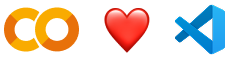

Try the new <a href="https://marketplace.visualstudio.com/items?itemName=Google.colab">Google Colab extension</a> for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the <strong><em>Extensions</em></strong> view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any <code>.ipynb</code> notebook file in your local workspace and either running a cell or clicking the <strong><em>Select kernel</em></strong> button in the top right.
*  Click <strong><em>Colab</em></strong> and then select your desired runtime, sign in with your Google Account and you're all set!

See more details in our <a href="https://developers.googleblog.com/google-colab-is-coming-to-vs-code">announcement blog here</a>.

In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb
}

results = []

for model_name, y_pred in models.items():
    results.append([
        model_name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

comparison_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.655125,0.564453,0.327185,0.414250
1,Decision Tree,0.571975,0.428340,0.443423,0.435751
2,Random Forest,0.649450,0.551950,0.316051,0.401945
3,Gradient Boosting,0.658075,0.574092,0.320142,0.411058


In [18]:
comparison_df.to_csv("model_comparison.csv", index=False)
print("Updated CSV saved")

Updated CSV saved


In [19]:
models.keys()

dict_keys(['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'])

In [20]:
print(models["Logistic Regression"])

[1 0 0 ... 0 0 1]


In [21]:
type(models["Logistic Regression"])

numpy.ndarray

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_test, models["Logistic Regression"]))

              precision    recall  f1-score   support

           0       0.68      0.85      0.76     25091
           1       0.56      0.33      0.41     14909

    accuracy                           0.66     40000
   macro avg       0.62      0.59      0.58     40000
weighted avg       0.64      0.66      0.63     40000



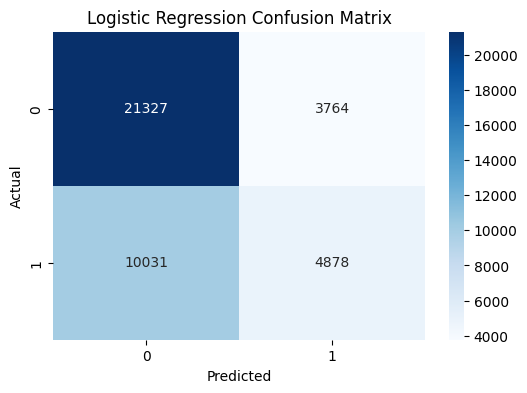

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

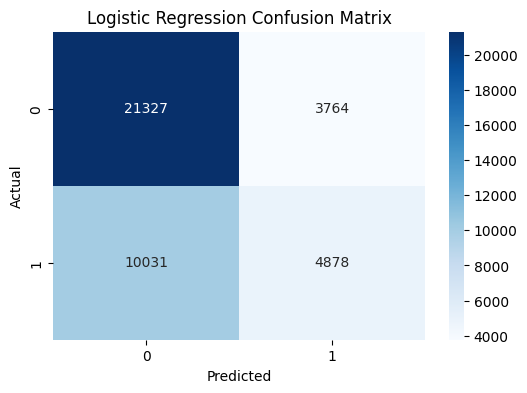

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, models["Logistic Regression"])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.savefig("confusion_matrix.png")
plt.show()

In [25]:
models

{'Logistic Regression': array([1, 0, 0, ..., 0, 0, 1]),
 'Decision Tree': array([1, 0, 0, ..., 1, 1, 0]),
 'Random Forest': array([1, 0, 0, ..., 0, 0, 1]),
 'Gradient Boosting': array([1, 0, 0, ..., 0, 0, 0])}

In [26]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                            DataFrame                             customer_id  age <...>200000 rows x 17 columns]
X_test                       DataFrame                             customer_id  age <...>[40000 rows x 17 columns]
X_train                      DataFrame                             customer_id  age <...>160000 rows x 17 columns]
accuracy                     float                       

In [27]:
lr = LogisticRegression(max_iter=1000)

In [28]:
import joblib

joblib.dump(lr, "best_model.pkl")

print("Best model saved successfully!")

Best model saved successfully!


In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160000, 17)
(40000, 17)
(160000,)
(40000,)


In [ ]:
import joblib
from sklearn.metrics import f1_score

# Load model
model = joblib.load("best_model.pkl")

# Predictions
y_pred = model.predict(X_test)

# Baseline F1 Score
baseline_f1 = f1_score(y_test, y_pred, average='weighted')

print("Baseline F1 Score:", baseline_f1)

In [45]:
type(model)
print(model)

LogisticRegression(max_iter=1000)


In [46]:
lr = LogisticRegression(max_iter=1000)
joblib.dump(lr, "best_model.pkl")

['best_model.pkl']

In [47]:
%whos

Variable                     Type                          Data/Info
--------------------------------------------------------------------
DecisionTreeClassifier       ABCMeta                       <class 'sklearn.tree._cla<...>.DecisionTreeClassifier'>
GradientBoostingClassifier   ABCMeta                       <class 'sklearn.ensemble.<...>dientBoostingClassifier'>
GridSearchCV                 ABCMeta                       <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
LogisticRegression           type                          <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
RandomForestClassifier       ABCMeta                       <class 'sklearn.ensemble.<...>.RandomForestClassifier'>
X                            DataFrame                             customer_id  age <...>200000 rows x 17 columns]
X_test                       DataFrame                             customer_id  age <...>[40000 rows x 17 columns]
X_train                      DataFrame                   

In [48]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
from sklearn.metrics import f1_score

y_pred = lr.predict(X_test)

baseline_f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Baseline F1 Score:", baseline_f1)

Baseline F1 Score: 0.6283829126170374


In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='f1_weighted'
)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

CV Scores: [0.629355   0.62911333 0.62983469 0.62879636 0.63574911]
Mean CV Score: 0.6305696984173329
Standard Deviation: 0.0026118101224853313


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1],
    'max_iter': [1000, 2000, 3000],
    'solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 0.01, 'max_iter': 3000, 'solver': 'lbfgs'}
Best CV Score: 0.6327669020520847


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
from sklearn.metrics import f1_score

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    average='weighted'
)

print("Tuned F1 Score:", tuned_f1)

Tuned F1 Score: 0.631431207220349


In [51]:
import joblib

joblib.dump(
    best_model,
    'tuned_model.pkl'
)

print("Tuned model saved successfully!")

Tuned model saved successfully!


In [37]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Baseline Logistic Regression',
              'Tuned Logistic Regression'],
    'F1 Score': [0.6283829126170374,
                 0.631431207220349]
})

comparison

,Model,F1 Score
0,Baseline Logistic Regression,0.628383
1,Tuned Logistic Regression,0.631431


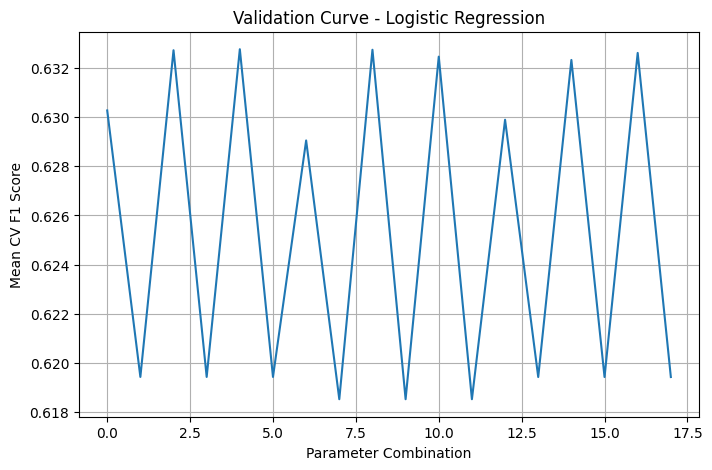

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(results['mean_test_score'])
plt.xlabel('Parameter Combination')
plt.ylabel('Mean CV F1 Score')
plt.title('Validation Curve - Logistic Regression')
plt.grid(True)

plt.savefig('validation_curve.png', bbox_inches='tight')
plt.show()

In [53]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [54]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)

churn
0    100482
1     59518
Name: count, dtype: int64
churn
0    62.80125
1    37.19875
Name: proportion, dtype: float64


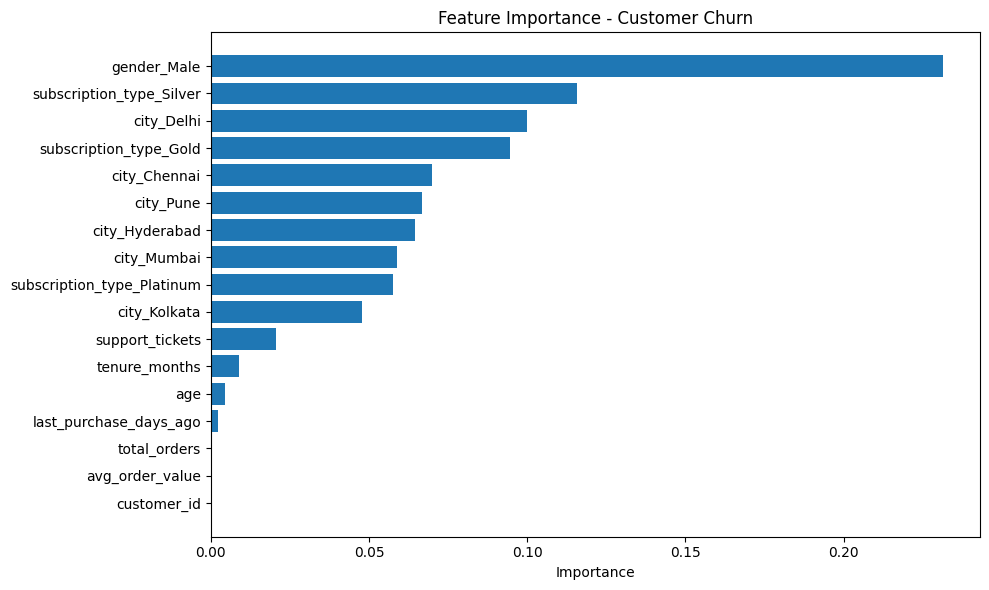

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(lr.coef_[0])
})

coef_df = coef_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10,6))
plt.barh(coef_df['Feature'], coef_df['Importance'])
plt.xlabel("Importance")
plt.title("Feature Importance - Customer Churn")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

In [56]:
def explain_prediction(model, feature_names):

    coef_values = abs(model.coef_[0])

    feature_scores = list(zip(feature_names, coef_values))

    feature_scores.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_3 = feature_scores[:3]

    print("Top 3 features influencing churn prediction:")

    for i, (name, score) in enumerate(top_3, 1):
        print(f"{i}. {name} (score: {score:.4f})")

    return top_3


explain_prediction(lr, X_train.columns)

Top 3 features influencing churn prediction:
1. gender_Male (score: 0.2315)
2. subscription_type_Silver (score: 0.1158)
3. city_Delhi (score: 0.1000)


[('gender_Male', np.float64(0.23151754922995146)),
 ('subscription_type_Silver', np.float64(0.11583271299244316)),
 ('city_Delhi', np.float64(0.10002275287210144))]

In [58]:
def enrich_churn(probability):

    churn_pct = probability * 100

    if churn_pct >= 75:
        risk = "High Risk"
        tips = [
            "Offer a loyalty discount immediately",
            "Assign a dedicated account manager",
            "Provide a free service upgrade"
        ]

    elif churn_pct >= 40:
        risk = "Medium Risk"
        tips = [
            "Send a personalised re-engagement email",
            "Offer a one-time discount",
            "Customer satisfaction call"
        ]

    else:
        risk = "Low Risk"
        tips = [
            "Continue engagement emails",
            "Invite to loyalty rewards",
            "Ask for referral"
        ]

    return {
        "churn_probability": f"{churn_pct:.1f}%",
        "risk_level": risk,
        "tips": tips
    }

print(enrich_churn(0.82))

{'churn_probability': '82.0%', 'risk_level': 'High Risk', 'tips': ['Offer a loyalty discount immediately', 'Assign a dedicated account manager', 'Provide a free service upgrade']}


In [59]:
print(X_train.columns.tolist())

['customer_id', 'age', 'tenure_months', 'avg_order_value', 'total_orders', 'last_purchase_days_ago', 'support_tickets', 'gender_Male', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Kolkata', 'city_Mumbai', 'city_Pune', 'subscription_type_Gold', 'subscription_type_Platinum', 'subscription_type_Silver']


In [60]:
import pandas as pd

samples = [

# Sample 1 - High Risk Customer
{
    'customer_id': 200001,
    'age': 25,
    'tenure_months': 2,
    'avg_order_value': 300,
    'total_orders': 3,
    'last_purchase_days_ago': 90,
    'support_tickets': 5,
    'gender_Male': 1,
    'city_Chennai': 0,
    'city_Delhi': 1,
    'city_Hyderabad': 0,
    'city_Kolkata': 0,
    'city_Mumbai': 0,
    'city_Pune': 0,
    'subscription_type_Gold': 0,
    'subscription_type_Platinum': 0,
    'subscription_type_Silver': 1
},

# Sample 2 - Loyal Customer
{
    'customer_id': 200002,
    'age': 40,
    'tenure_months': 36,
    'avg_order_value': 2500,
    'total_orders': 50,
    'last_purchase_days_ago': 5,
    'support_tickets': 0,
    'gender_Male': 0,
    'city_Chennai': 0,
    'city_Delhi': 0,
    'city_Hyderabad': 1,
    'city_Kolkata': 0,
    'city_Mumbai': 0,
    'city_Pune': 0,
    'subscription_type_Gold': 1,
    'subscription_type_Platinum': 0,
    'subscription_type_Silver': 0
},

# Sample 3
{
    'customer_id': 200003,
    'age': 32,
    'tenure_months': 12,
    'avg_order_value': 1200,
    'total_orders': 20,
    'last_purchase_days_ago': 20,
    'support_tickets': 2,
    'gender_Male': 1,
    'city_Chennai': 0,
    'city_Delhi': 0,
    'city_Hyderabad': 0,
    'city_Kolkata': 0,
    'city_Mumbai': 1,
    'city_Pune': 0,
    'subscription_type_Gold': 0,
    'subscription_type_Platinum': 1,
    'subscription_type_Silver': 0
},

# Sample 4
{
    'customer_id': 200004,
    'age': 28,
    'tenure_months': 6,
    'avg_order_value': 700,
    'total_orders': 8,
    'last_purchase_days_ago': 45,
    'support_tickets': 4,
    'gender_Male': 1,
    'city_Chennai': 1,
    'city_Delhi': 0,
    'city_Hyderabad': 0,
    'city_Kolkata': 0,
    'city_Mumbai': 0,
    'city_Pune': 0,
    'subscription_type_Gold': 0,
    'subscription_type_Platinum': 0,
    'subscription_type_Silver': 1
},

# Sample 5
{
    'customer_id': 200005,
    'age': 50,
    'tenure_months': 60,
    'avg_order_value': 3500,
    'total_orders': 100,
    'last_purchase_days_ago': 2,
    'support_tickets': 0,
    'gender_Male': 0,
    'city_Chennai': 0,
    'city_Delhi': 0,
    'city_Hyderabad': 0,
    'city_Kolkata': 0,
    'city_Mumbai': 0,
    'city_Pune': 1,
    'subscription_type_Gold': 0,
    'subscription_type_Platinum': 1,
    'subscription_type_Silver': 0
}
]

for i, sample in enumerate(samples, 1):
    sample_df = pd.DataFrame([sample])

    prediction = lr.predict(sample_df)[0]
    probability = lr.predict_proba(sample_df)[0][1]

    result = enrich_churn(probability)

    print(f"\nSample {i}")
    print(result)


Sample 1
{'churn_probability': '25.8%', 'risk_level': 'Low Risk', 'tips': ['Continue engagement emails', 'Invite to loyalty rewards', 'Ask for referral']}

Sample 2
{'churn_probability': '18.4%', 'risk_level': 'Low Risk', 'tips': ['Continue engagement emails', 'Invite to loyalty rewards', 'Ask for referral']}

Sample 3
{'churn_probability': '21.1%', 'risk_level': 'Low Risk', 'tips': ['Continue engagement emails', 'Invite to loyalty rewards', 'Ask for referral']}

Sample 4
{'churn_probability': '23.0%', 'risk_level': 'Low Risk', 'tips': ['Continue engagement emails', 'Invite to loyalty rewards', 'Ask for referral']}

Sample 5
{'churn_probability': '14.8%', 'risk_level': 'Low Risk', 'tips': ['Continue engagement emails', 'Invite to loyalty rewards', 'Ask for referral']}


In [61]:
print("Training Accuracy:", lr.score(X_train, y_train))
print("Testing Accuracy:", lr.score(X_test, y_test))

Training Accuracy: 0.6563375
Testing Accuracy: 0.655125


## 🎁 Free-of-charge Pro plan for Gemini and Colab for US university students 🎓

Get more access to our most accurate model Gemini 3 Pro for advanced coding, complex research and innovative projects, backed by Colab's dedicated high-compute resources for data science and machine learning.

Get the Gemini free-of-charge offer at <a href="https://gemini.google/students?utm_source=colab&amp;utm_medium=banner&amp;utm_campaign=students_xpa_us-colab-banner">gemini.google/students</a>.  
Get the Colab free-of-charge offer at <a href="https://colab.research.google.com/signup">colab.research.google.com/signup</a>.  
Terms apply.

## Access popular AI models via Google Colab-AI without an API key
All users have access to most popular LLMs via the <code>google-colab-ai</code> Python library, and paid users have access to a wider selection of models. For more details, refer to <a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb">getting started with Google Colab AI</a>.



In [34]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code and audio.

**How to get started**
*  Go to <a href="https://aistudio.google.com/">Google AI Studio</a> and log in with your Google Account.
*  <a href="https://aistudio.google.com/app/apikey">Create an API key</a>.
* Use a quickstart for <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb">Python</a> or call the REST API using <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb">curl</a>.

**Discover Gemini's advanced capabilities**
*  Play with Gemini <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb">multimodal outputs</a>, mixing text and images in an iterative way.
*  Discover the <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb">multimodal Live API</a> &#40;demo <a href="https://aistudio.google.com/live">here</a>&#41;.
*  Learn how to <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb&quot;">analyse images and detect items in your pictures</a> using Gemini &#40;bonus, there's a <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb">3D version</a> as well!&#41;.
*  Unlock the power of the <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb">Gemini thinking model</a>, capable of solving complex tasks with its inner thoughts.
      
**Explore complex use cases**
*  Use <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb">Gemini grounding capabilities</a> to create a report on a company based on what the model can find on the Internet.
*  Extract <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb">invoices and form data from PDFs</a> in a structured way.
*  Create <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb">illustrations based on a whole book</a> using Gemini large context window and Imagen.

To learn more, take a look at the <a href="https://github.com/google-gemini/cookbook">Gemini cookbook</a> or visit the <a href="https://ai.google.dev/docs/">Gemini API documentation</a>.


Colab now has AI features powered by <a href="https://gemini.google.com">Gemini</a>. The video below provides information on how to use these features, whether you're new to Python or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  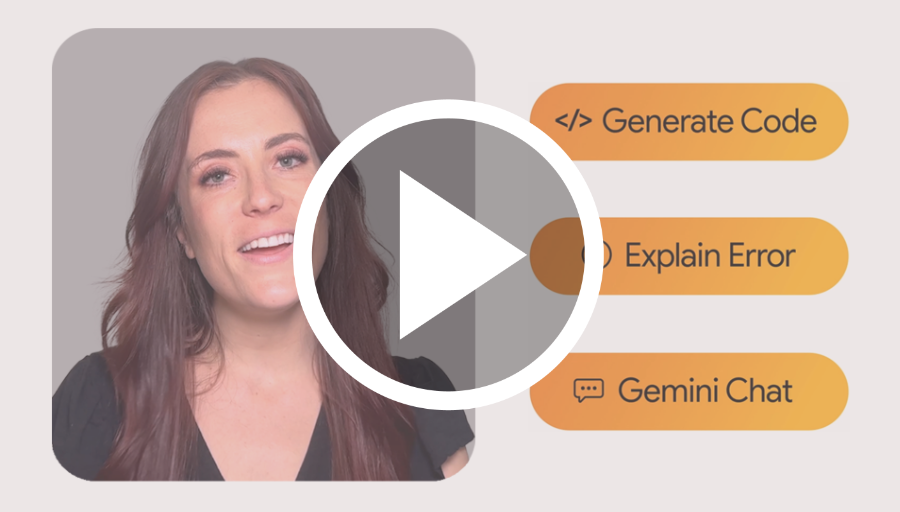
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or ‘Colaboratory’, allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a <strong>student</strong>, a <strong>data scientist</strong> or an <strong>AI researcher</strong>, Colab can make your work easier. Watch <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Introduction to Colab</a> or <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Colab features you may have missed</a> to learn more or just get started below!

<div class="markdown-google-sans">

## <strong>Getting started</strong>
</div>

The document that you are reading is not a static web page, but an interactive environment called a <strong>Colab notebook</strong> that lets you write and execute code.

For example, here is a <strong>code cell</strong> with a short Python script that computes a value, stores it in a variable and prints the result:

In [32]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut 'Command/Ctrl+Enter'. To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [33]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine <strong>executable code</strong> and <strong>rich text</strong> in a single document, along with <strong>images</strong>, <strong>HTML</strong>, <strong>LaTeX</strong> and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To find out more, see <a href="/notebooks/basic_features_overview.ipynb">Overview of Colab</a>. To create a new Colab notebook you can use the File menu above, or use the following link: <a href="http://colab.research.google.com#create=true">Create a new Colab notebook</a>.

Colab notebooks are Jupyter notebooks that are hosted by Colab. To find out more about the Jupyter project, see <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyse and visualise data. The code cell below uses <strong>numpy</strong> to generate some random data, and uses <strong>matplotlib</strong> to visualise it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from GitHub and many other sources. To find out more about importing data, and how Colab can be used for data science, see the links below under <a href="#working-with-data">Working with data</a>.

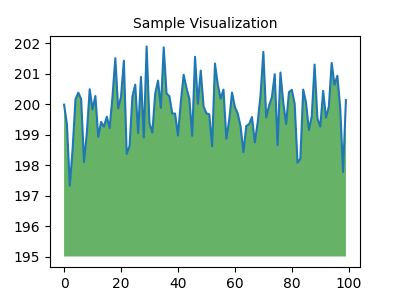

In [31]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning that you can leverage the power of Google hardware, including <a href="#using-accelerated-hardware">GPUs and TPUs</a>, regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for <strong>pandas</strong> code to finish running and want to go faster, you can switch to a GPU runtime and use libraries like <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a> that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">10-minute guide</a> or
 <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">US stock market data analysis demo</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it and evaluate the model, all in just <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">a few lines of code</a>.

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the <a href="#machine-learning-examples">machine learning examples</a> below.

<div class="markdown-google-sans">

## More resources

### Working with notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with data
</div>

- [Loading data: Drive, Sheets and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualising data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine learning

<div>

These are a few of the notebooks related to machine learning, including Google's online machine learning course. See the <a href="https://developers.google.com/machine-learning/crash-course/">full course website</a> for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using accelerated hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer &#40;ViT&#41; for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- <a href="https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html">Train a miniGPT language model with JAX AI stack</a>
- <a href="https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb">LoRA/QLoRA finetuning for LLM using Tunix</a>
- <a href="https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/">Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA</a>
- <a href="https://keras.io/keras_hub/guides/hugging_face_keras_integration/">Loading Hugging Face transformers checkpoints</a>
- <a href="https://keras.io/guides/int8_quantization_in_keras/">8-bit integer quantisation in Keras</a>
- <a href="https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/">Float8 training and inference with a simple transformer model</a>
- <a href="https://keras.io/keras_hub/guides/transformer_pretraining/">Pretraining a transformer from scratch with KerasHub</a>
- <a href="https://keras.io/examples/vision/mnist_convnet/">Simple MNIST convnet</a>
- <a href="https://keras.io/examples/vision/image_classification_from_scratch/">Image classification from scratch using Keras 3</a>
- <a href="https://keras.io/keras_hub/guides/classification_with_keras_hub/">Image classification with KerasHub</a>
